In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
from geomloss import SamplesLoss

In [2]:
device = "mps" if torch.backends.mps.is_available() else "cpu"

### Posterior

Two uniform 2D squares with side-length 1 and centered at $(\frac{3}{2}, \frac{3}{2})$ and $(-\frac{3}{2}, -\frac{3}{2})$

In [3]:
def sample_data(n, rng=None):
    n1 = n // 2
    n2 = n - n1

    sq1 = torch.rand(n1, 2, generator=rng) * 1.0 + torch.tensor([-2.0, -2.0])
    sq2 = torch.rand(n2, 2, generator=rng) * 1.0 + torch.tensor([1.0, 1.0])

    return torch.cat([sq1, sq2], dim=0).to(device)

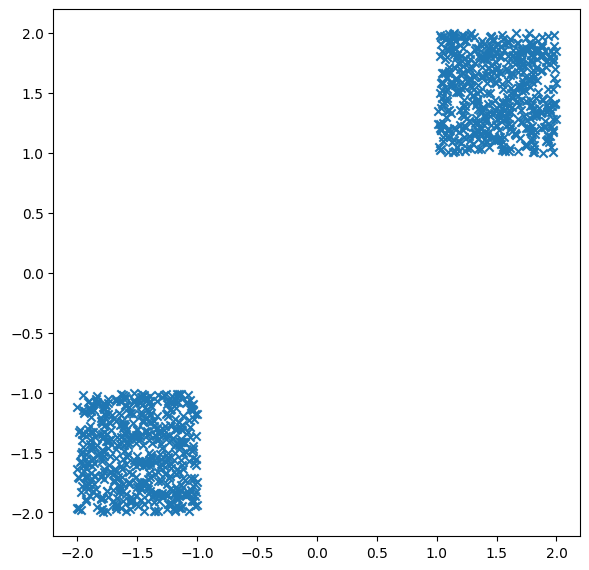

In [4]:
X = sample_data(1000).cpu()

fig, ax = plt.subplots(figsize=(6, 6), tight_layout=True)
ax.scatter(X[:, 0], X[:, 1], marker="x")
ax.set_aspect("equal")

### Energy Field

- $d_1$: shortest distance to square 1
- $d_2$: shortest distance to square 2
- $\sigma$ parameter determining the width of energy barrier

$$
\Large{E = -e^{-\frac{d_1^{2} + d_2^{2}}{2\sigma^2}}}
$$

In [5]:
def energy(x, sigma=0.5):
    def in_square(x, xmin, xmax, ymin, ymax):
        in_x = (xmin < x[:, 0]) & (x[:, 0] < xmax)
        in_y = (ymin < x[:, 1]) & (x[:, 1] < ymax)

        return in_x & in_y

    in_square_1 = in_square(x, 1, 2, 1, 2)
    in_square_2 = in_square(x, -2, -1, -2, -1)
    E = torch.where(in_square_1 | in_square_2, 0.0, 1.0)

    return E

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4324.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


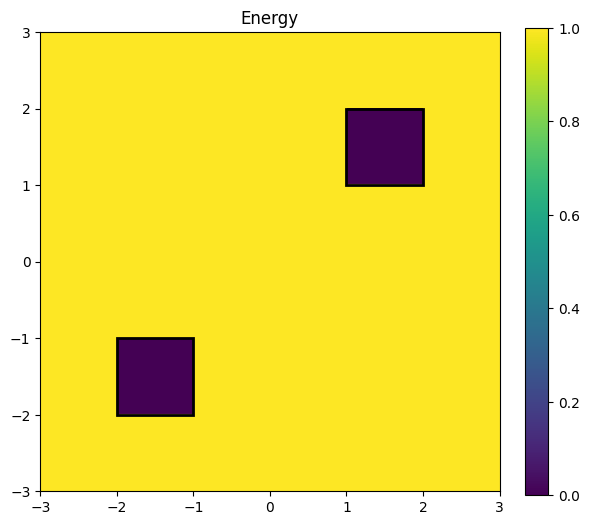

In [6]:
extent = 3
x = torch.linspace(-extent, extent, 400)
y = torch.linspace(-extent, extent, 400)
X, Y = torch.meshgrid(x, y)
Z = energy(torch.stack([X.flatten(), Y.flatten()], dim=1)).reshape(X.shape).cpu()

fig, ax = plt.subplots(figsize=(6, 6), tight_layout=True)

ax.add_patch(Rectangle((-2, -2), 1, 1, edgecolor='black', facecolor='none', lw=2))
ax.add_patch(Rectangle((1, 1), 1, 1, edgecolor='black', facecolor='none', lw=2))
ax.grid(False)

im = ax.imshow(Z, extent=(-extent, extent, -extent, extent), origin="lower", cmap='viridis')

ax.set_title("Energy")

_ = fig.colorbar(im, ax=ax, fraction=0.046)

In [7]:
T = 100
betas = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

lambda_t = torch.linspace(3.0, 0.0, T).to(device)

Text(0.5, 1.0, '$\\bar{\\alpha}_t$')

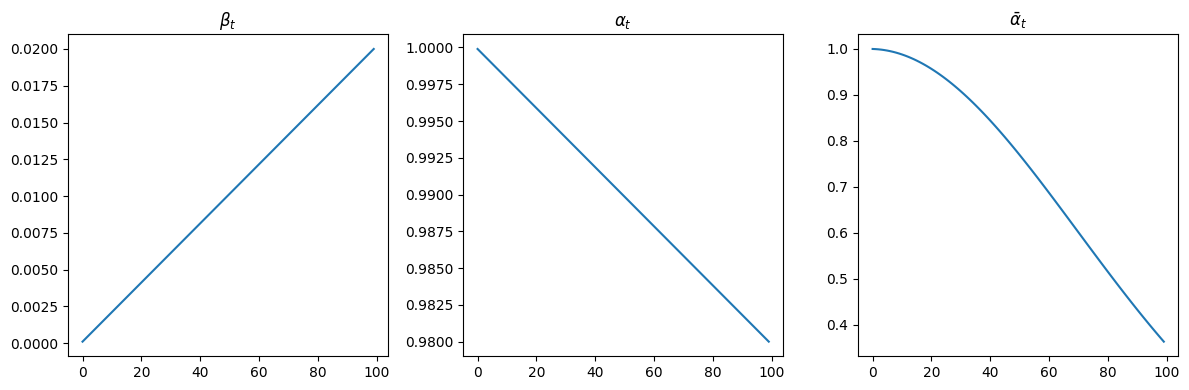

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)
axs[0].plot(betas.cpu())
axs[1].plot(alphas.cpu())
axs[2].plot(alphas_cumprod.cpu())

axs[0].set_title(r"$\beta_t$")
axs[1].set_title(r"$\alpha_t$")
axs[2].set_title(r"$\bar{\alpha}_t$")

In [9]:
def q_sample(x0, t, noise):
    a_bar = alphas_cumprod[t].view(-1, 1)
    return torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise

In [10]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x, t):
        t = t.float() / T
        t = t.unsqueeze(1)
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

## Experiments

1. **Baseline**
    - Training: $\mathcal{L} = \lvert \epsilon^{*} - \epsilon_\theta \rvert^2$
2. **Boltzmann Weighted Loss**
    - Training: $\mathcal{L} = w(\hat{x}_0) \lvert \epsilon^{*} - \epsilon_\theta \rvert^2$
    - $w(\hat{x}_0) \propto \exp{\left(\lambda_t E(\hat{x}_0)\right)}$

In [11]:
def train(mode="baseline", epochs=2000, batch_size=512):
    torch.manual_seed(0)
    model = MLP().to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)

    for step in range(epochs):
        x0 = sample_data(batch_size)
        t = torch.randint(0, T, (x0.size(0),), device=device)

        noise = torch.randn_like(x0)
        xt = q_sample(x0, t, noise)
        xt.requires_grad_(True)

        pred = model(xt, t)
        target = noise

        if mode == "baseline":
            weight = 1.0
        elif mode == "weighted":
            alpha_bar = alphas_cumprod[t, None]
            x0_hat = (xt - torch.sqrt(1 - alpha_bar) * pred.detach()) / torch.sqrt(alpha_bar)
            E = energy(x0_hat)[:, None].detach()
            weight = torch.exp(lambda_t[t, None] * E).detach()
        else:
            raise ValueError("Invalid Training Mode")

        loss = (weight * ((pred - target) ** 2)).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % 200 == 0:
            print(f"{mode} step {step} loss {loss.item():.4f}")

    return model

In [12]:
def sample(model, n=2000, rng=None):
    if rng is None:
        rng = torch.Generator()
        rng.manual_seed(0)
    
    x = torch.randn(n, 2, generator=rng).to(device)

    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)
        pred = model(x, t_batch)

        alpha = alphas[t]
        alpha_bar = alphas_cumprod[t]

        score = -pred / torch.sqrt(1 - alpha_bar)

        noise = torch.randn(x.shape, generator=rng).to(device) if t > 0 else 0

        x = 1 / torch.sqrt(alpha) * (x + (1 - alpha) * score) + torch.sqrt(betas[t]) * noise
        x = x.detach()

    return x.cpu()

In [13]:
model_weighted = train("weighted")
model_baseline = train("baseline")

weighted step 0 loss 3.5676
weighted step 200 loss 0.5180
weighted step 400 loss 0.5600
weighted step 600 loss 0.4171
weighted step 800 loss 0.4566
weighted step 1000 loss 0.4106
weighted step 1200 loss 0.4016
weighted step 1400 loss 0.4507
weighted step 1600 loss 0.6247
weighted step 1800 loss 0.5390
baseline step 0 loss 0.9969
baseline step 200 loss 0.4015
baseline step 400 loss 0.4224
baseline step 600 loss 0.3684
baseline step 800 loss 0.4148
baseline step 1000 loss 0.3861
baseline step 1200 loss 0.3555
baseline step 1400 loss 0.4135
baseline step 1600 loss 0.3898
baseline step 1800 loss 0.4619


In [14]:
samples_baseline = sample(model_baseline.to(device))
samples_weighted = sample(model_weighted.to(device))

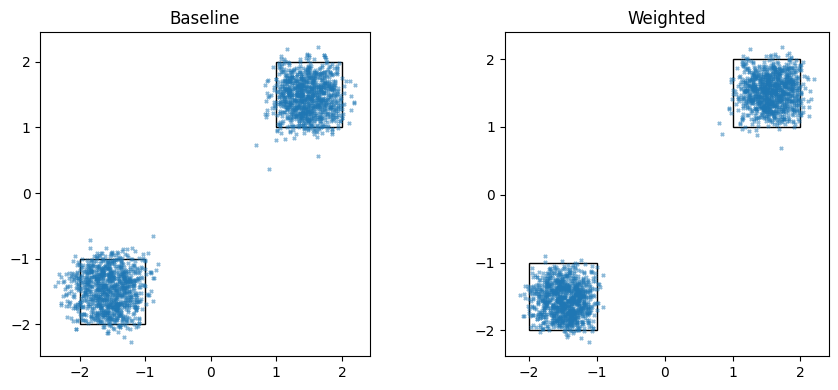

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)

for ax in axs:
    ax.set_aspect("equal")
    ax.grid(False)

    ax.add_patch(Rectangle((-2, -2), 1, 1, edgecolor="black", facecolor="none"))
    ax.add_patch(Rectangle((1, 1), 1, 1, edgecolor="black", facecolor="none"))

axs[0].set_title("Baseline")
axs[0].scatter(samples_baseline[:, 0], samples_baseline[:, 1], s=5, marker="x", alpha=0.5)

axs[1].set_title("Weighted")
axs[1].scatter(samples_weighted[:, 0], samples_weighted[:, 1], s=5, marker="x", alpha=0.5)


In [16]:
def fraction_outside(x):
    # x: (N, 2) tensor
    mask_sq1 = (x[:,0] >= -2) & (x[:,0] <= -1) & (x[:,1] >= -2) & (x[:,1] <= -1)
    mask_sq2 = (x[:,0] >= 1) & (x[:,0] <= 2) & (x[:,1] >= 1) & (x[:,1] <= 2)
    inside = mask_sq1 | mask_sq2
    return 1 - inside.float().mean().item()

In [17]:
print(f"Fraction outside (Baseline): {fraction_outside(samples_baseline):.4f}")
print(f"Fraction outside (Weighted): {fraction_outside(samples_weighted):.4f}")

Fraction outside (Baseline): 0.1225
Fraction outside (Weighted): 0.0450


In [18]:
def mean_energy(x):
    return energy(x).mean().item()

In [19]:
print(f"Mean energy (Baseline): {mean_energy(samples_baseline):.4f}")
print(f"Mean energy (Weighted): {mean_energy(samples_weighted):.4f}")

Mean energy (Baseline): 0.1225
Mean energy (Weighted): 0.0450


In [20]:
def plot_score_field(
    model,
    ax,
    t=1,
    xlim=(-3, 3),
    ylim=(-3, 3),
    n=25,
    device="cpu",
    color_by_magnitude=True,
):
    model.eval()
    model = model.to(device)

    x_vals = torch.linspace(*xlim, n)
    y_vals = torch.linspace(*ylim, n)
    X, Y = torch.meshgrid(x_vals, y_vals)

    xy = torch.stack([X.flatten(), Y.flatten()], axis=1).to(torch.float32).to(device)

    t_tensor = torch.full((xy.shape[0],), t, dtype=torch.float32, device=device)

    with torch.no_grad():
        pred = model(xy, t_tensor)

    alpha_bar = alphas_cumprod[t].to(device)
    
    x0_hat = (xy - torch.sqrt(1 - alpha_bar) * pred) / torch.sqrt(alpha_bar)
    vec = x0_hat - xy
    
    s_x = vec[:, 0].cpu().reshape(X.shape)
    s_y = vec[:, 1].cpu().reshape(Y.shape)

    mag = torch.sqrt(s_x**2 + s_y**2) + 1e-8

    if color_by_magnitude:
        q = ax.quiver(X, Y, s_x, s_y, mag, cmap="viridis", scale=1, scale_units="xy", alpha=0.5)
    else:
        q = ax.quiver(X, Y, s_x, s_y, scale=1, scale_units="xy", alpha=0.5)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    ax.set_title(f"t = {t}")

    return q

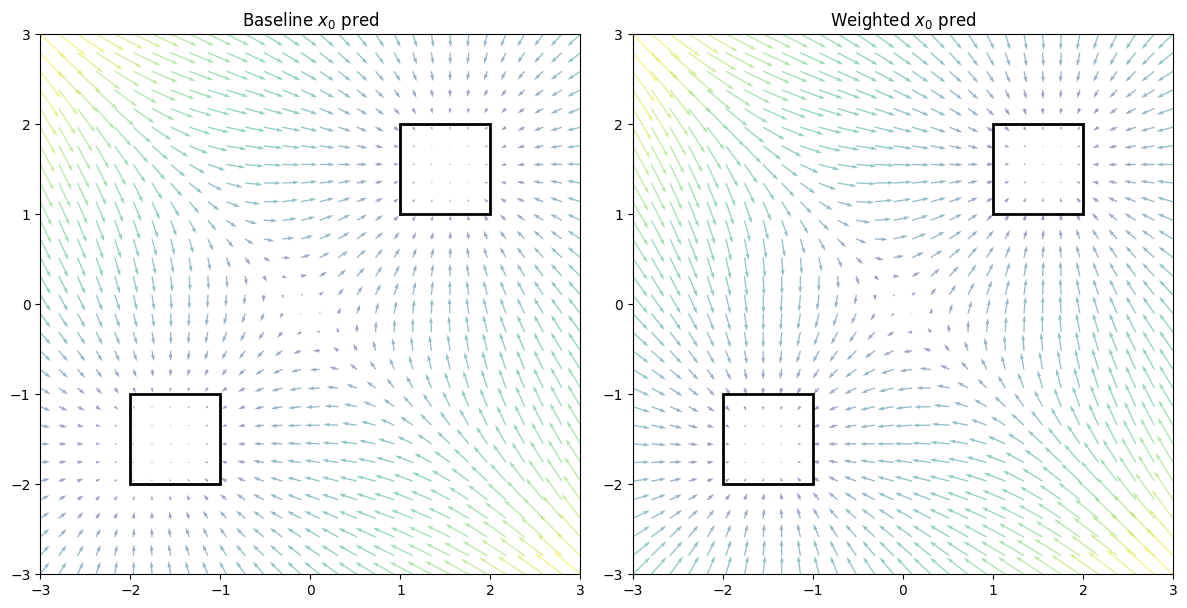

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)

t=5
plot_score_field(model_baseline, axs[0], t=t, n=30)
plot_score_field(model_weighted, axs[1], t=t, n=30)
                        
for ax in axs:
    ax.add_patch(Rectangle((-2, -2), 1, 1, edgecolor='black', facecolor='none', lw=2))
    ax.add_patch(Rectangle((1, 1), 1, 1, edgecolor='black', facecolor='none', lw=2))

_ = axs[0].set_title(r"Baseline $x_0$ pred")
_ = axs[1].set_title(r"Weighted $x_0$ pred")

### Sinkhorn Loss (Regularized Wasserstein Distance)

Given two sets of samples $ X = \{x_i\} $ and $ Y = \{y_j\} $, the Wasserstein distance measures the minimum "cost" of transporting mass from $ X $ to match $ Y $, where cost is typically the squared Euclidean distance.

The Sinkhorn version introduces an **entropy regularization** term:

$$
W_\varepsilon(X, Y) = \min_{\pi} \sum_{i,j} \pi_{ij} c(x_i, y_j)
+ \varepsilon \sum_{i,j} \pi_{ij} \log \pi_{ij}
$$

- $ \pi_{ij} $: transport plan between points  
- $ c(x_i, y_j) $: cost function (e.g., $ \|x_i - y_j\|^2 $)  
- $ \varepsilon $: regularization strength  

In [22]:
loss = SamplesLoss(
    loss="sinkhorn",
    p=2,
    blur=0.1
)

rng = torch.Generator()
rng.manual_seed(0)
x_true = sample_data(2000, rng=rng).to(device)

dist_baseline = loss(x_true, samples_baseline.to(device))
dist_weighted = loss(x_true, samples_weighted.to(device))

In [23]:
print(f"Sinkhorn (Baseline): {dist_baseline:.4f}")
print(f"Sinkhorn (Weighted): {dist_weighted:.4f}")

Sinkhorn (Baseline): 0.0027
Sinkhorn (Weighted): 0.0052
